In [44]:
import numpy as np
import psfsim
import matplotlib.pyplot as plt
import matplotlib as mpl

from psfsim.polychrom import PolychromaticPSF
# from psfsim.psfobject import PSFObject

This notebook contains my experiments (and some completed functions) for the purposes:
* Generating PSFs with many frequencies at once using `PolychromaticPSF`
* Downsampling PSFs to native Roman resolution
* Fitting diffraction spikes to the downsampled PSFs
* Looking at changes in spike locations between oversampled and native resolution PSFs for none of and some aberrations
* Building a response matrix naively (doesn't work that well)
* Poisson resampling a PSF

The band used here is approximately H158

In [45]:
h_band_wl = np.linspace( 1.4, 1.8, 10 ) # microns
poly = PolychromaticPSF( 9,0,0, h_band_wl )

# as of 6/24/2026 the postage_stamp_size argument does nothing
poly.compute_poly_psf( postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=8 );
poly_ideal = np.log10( np.abs( poly.chromatic_psf ) )

poly.compute_poly_psf( postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=8, extra_aberrations=( None, None, 0.1 ) );
poly_unfocused = np.log10( np.abs( poly.chromatic_psf ) )

poly.compute_poly_psf( postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=8, extra_aberrations=( None, None, -0.1 ) );
poly_unfocused_n = np.log10( np.abs( poly.chromatic_psf ) )

poly.compute_poly_psf( postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96, ovsamp=8, extra_aberrations=( None, None, 0.02 ) )
poly_unfocused_small = np.log10( np.abs( poly.chromatic_psf ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [46]:
# poly.compute_poly_psf(
#     postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96,
#     ovsamp=8, extra_aberrations=( None, None, 0.1, 0.1, 0.1 )
# )
poly.compute_poly_psf(
    postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96,
    ovsamp=8, extra_aberrations=( None, None, 0.1 )
)
poly_unfocused = np.log10( np.abs( poly.chromatic_psf ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [47]:
a = np.arange( 8 )
b, c = np.meshgrid( a, a )
# index_arr = np.array( (
#     ( 
# ) )
index_arr = np.array( ( ( 1, 2 ), ( 3, 4 ) ) )
print( b )
print( index_arr )
print( b[ index_arr, index_arr ] )
print( c )
print( b.flatten( ) )
print( c.flatten( ) )

d = np.full( ( 2, 2, 2 ), ( 5, 9 ) )

[[0 1 2 3 4 5 6 7]
 [0 1 2 3 4 5 6 7]
 [0 1 2 3 4 5 6 7]
 [0 1 2 3 4 5 6 7]
 [0 1 2 3 4 5 6 7]
 [0 1 2 3 4 5 6 7]
 [0 1 2 3 4 5 6 7]
 [0 1 2 3 4 5 6 7]]
[[1 2]
 [3 4]]
[[1 2]
 [3 4]]
[[0 0 0 0 0 0 0 0]
 [1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2]
 [3 3 3 3 3 3 3 3]
 [4 4 4 4 4 4 4 4]
 [5 5 5 5 5 5 5 5]
 [6 6 6 6 6 6 6 6]
 [7 7 7 7 7 7 7 7]]
[0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4
 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7 0 1 2 3 4 5 6 7]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 4 4 4 4 4
 4 4 4 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6 7 7 7 7 7 7 7 7]


Downsampling by taking the mean of subpixels of a given size

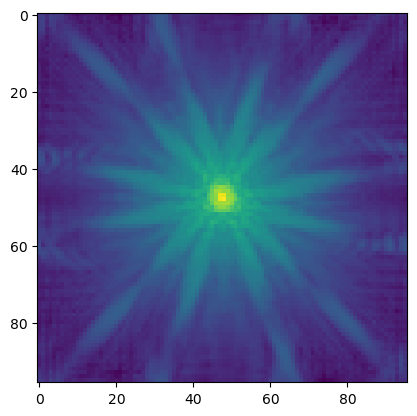

In [48]:
def downsample_2d_image( image, pixel_size=8 ): # ONLY WORKS ON 2D IMAGES
    assert( len( image.shape ) == 2 )
    subpixel_side = np.arange( pixel_size )
    subpixel_cols, subpixel_rows = np.meshgrid( subpixel_side, subpixel_side )
    # example in these comments is pixel_size = 8, image size is 768 x 768, downsampled image is 768/8 = 96 pixels square
    # subpixel_rows & cols are shape 8, 8 and looks like:
    #      rows             columns
    # ( 0 0 ... 0 )     ( 0 1 2 ... 7 )
    # ( 1 1 ... 1 )     ( 0 1 2 ... 7 )
    # ( 2 2 ... 2 ) and ( 0 1 2 ... 7 )
    # ( ... ... . )     ( ...   ... . )
    # ( 7 7 ... 7 )     ( 0 1 2 ... 7 )
    # these arrays are indices within a subpixel at the top left corner of the image.
    
    dsamp_size = image.shape[0] // pixel_size
    pixels_side = np.arange( dsamp_size ) * pixel_size
    pixels_cols, pixels_rows = np.meshgrid( pixels_side, pixels_side )
    
    # pixels_rows & cols are shape 96, 96 and looks like:
    #        rows                   columns
    # ( 0   0   ... 0   )     ( 0 8 16 ... 760 )
    # ( 8   8   ... 8   )     ( 0 8 16 ... 760 )
    # ( 16  16  ... 16  ) and ( 0 8 16 ... 760 )
    # ( ...     ... .   )     ( ...    ... .   )
    # ( 760 760 ... 760 )     ( 0 8 16 ... 760 )
    # these arrays are the indices at the top left corner of each subpixel

    # promote pixels_rows and pixels_cols to shape 96, 96, 1
    pixels_rows = pixels_rows[ :, :, np.newaxis ] 
    pixels_cols = pixels_cols[ :, :, np.newaxis ]

    idx_arr_subpixel_rows = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_rows.flatten( ) )
    idx_arr_subpixel_cols = np.full( ( dsamp_size, dsamp_size, pixel_size**2 ), subpixel_cols.flatten( ) )
    # idx_arr_subpixel_rows & cols are size 96, 96, 64 (matrix of 1d arrays) and look like:
    # 
    # ( subpixel_rows flattened, subpixel_rows flattened, ..., subpixel_rows flattened ) <- 96 copies
    # ( subpixel_rows flattened, subpixel_rows flattened, ..., subpixel_rows flattened ) <- 96 copies
    # ( ...,                     ...,                     ..., ...                     ) <- 96 rows total
    # ( subpixel_rows flattened, subpixel_rows flattened, ..., subpixel_rows flattened ) <- 96 copies
    # and
    # ( subpixel_cols flattened, subpixel_cols flattened, ..., subpixel_cols flattened ) <- 96 copies
    # ( subpixel_cols flattened, subpixel_cols flattened, ..., subpixel_cols flattened ) <- 96 copies
    # ( ...,                     ...,                     ..., ...                     ) <- 96 rows total
    # ( subpixel_cols flattened, subpixel_cols flattened, ..., subpixel_cols flattened ) <- 96 copies
    # where subpixel_rows flattened = ( 0, 0, ..., 0, 1, 1, ..., 1, ..., 7, 7, ..., 7 ) <- x8 of each number
    # and subpixel_cols flattened = ( 0, 1, 2, ..., 7, 0, 1, 2, ..., 7, ..., 0, 1, 2, ..., 7 ) <- x8 sequences
    
    
    idx_arr_rows = idx_arr_subpixel_rows + pixels_rows
    idx_arr_cols = idx_arr_subpixel_cols + pixels_cols
    # in the end we have two 96, 96, 64 arrays that have the 64 unique indices per subpixel in the 3rd axis of a 96x96 matrix of subpixels.
    # They look like:
    #
    # ( subpixel_rows flattened,       subpixel_rows flattened,       ..., subpixel_rows flattened       ) <- 96 copies
    # ( subpixel_rows flattened + 8,   subpixel_rows flattened + 8,   ..., subpixel_rows flattened + 8   ) <- 96 copies
    # ( ...,                           ...,                           ..., ...                           ) <- 96 rows total
    # ( subpixel_rows flattened + 760, subpixel_rows flattened + 760, ..., subpixel_rows flattened + 760 ) <- 96 copies
    # and
    # ( subpixel_cols flattened, subpixel_cols flattened + 8, ..., subpixel_cols flattened + 760 ) <- 96 copies
    # ( subpixel_cols flattened, subpixel_cols flattened + 8, ..., subpixel_cols flattened + 760 ) <- 96 copies
    # ( ...,                     ...,                         ..., ...                           ) <- 96 rows total
    # ( subpixel_cols flattened, subpixel_cols flattened + 8, ..., subpixel_cols flattened + 760 ) <- 96 copies

    # reference the image with our index arrays to get a new array with shape 96, 96, 64 and take the mean along the last axis
    pixelated_image = image[ idx_arr_rows, idx_arr_cols ]
    downsampled_image = np.mean( pixelated_image, axis=-1 )
    return downsampled_image


dsamp_poly_unfocused = downsample_2d_image( poly_unfocused, pixel_size=8 )
plt.imshow( dsamp_poly_unfocused )
# plt.xlim( 60, 70 )
# plt.ylim( 60, 50 )

(768, 768)


Text(0.5, 0.98, 'H band PSF with different amounts of focusing')

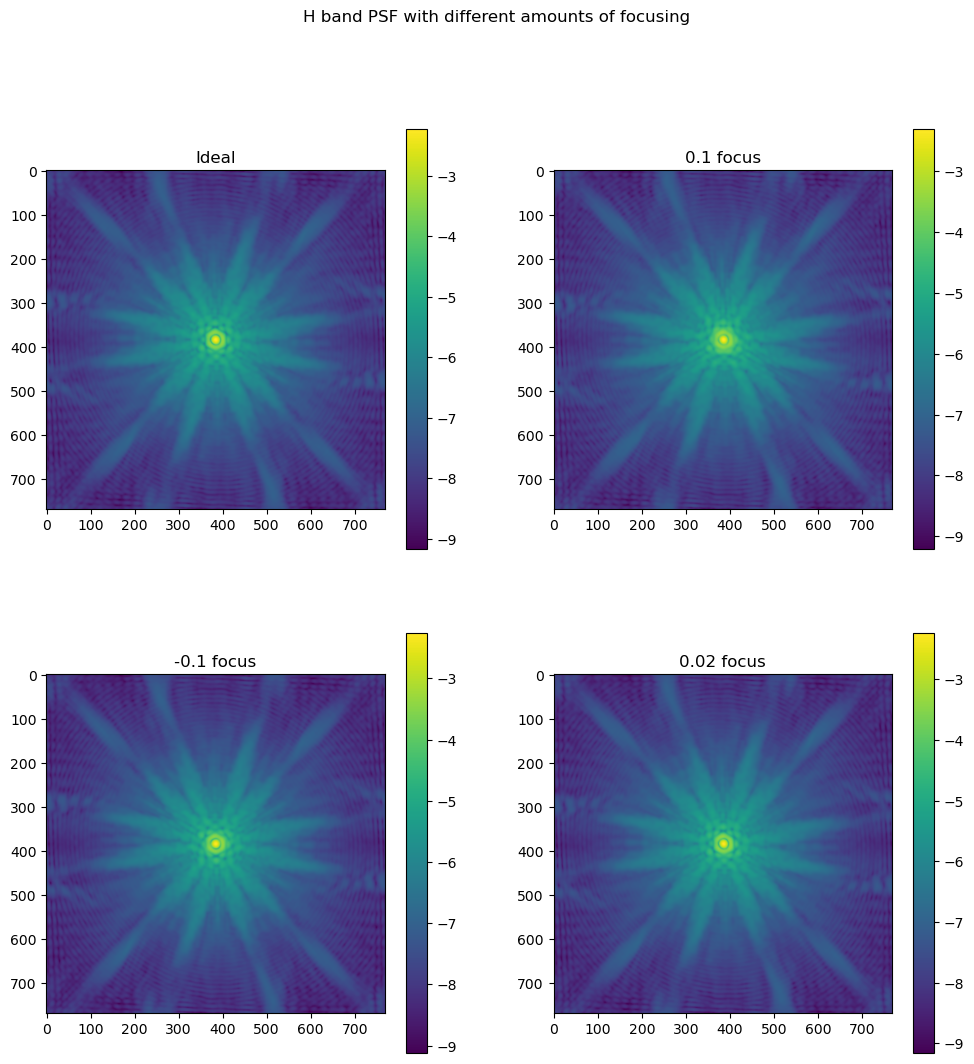

In [49]:
# I copied this from Nihar code (I think) but it is currently unused in this notebook

def center_crop(img, half_size=240):
    cy, cx = np.array(img.shape) // 2
    return img[cy-half_size:cy+half_size, cx-half_size:cx+half_size]

# img = np.log10( np.abs( poly.chromatic_psf ) )
# plt.imshow( center_crop( img ) )

fig, ax = plt.subplots( figsize=( 12, 12 ), ncols=2, nrows=2 )
im = ax[0,0].imshow( poly_ideal )
ax[0,0].set_title( 'Ideal' )
fig.colorbar( im, ax=ax[0,0] )

im = ax[0,1].imshow( poly_unfocused )
ax[0,1].set_title( '0.1 focus' )
fig.colorbar( im, ax=ax[0,1] )

im = ax[1,0].imshow( poly_unfocused_n )
ax[1,0].set_title( '-0.1 focus' )
fig.colorbar( im, ax=ax[1,0] )

im = ax[1,1].imshow( poly_unfocused_small )
ax[1,1].set_title( '0.02 focus' )
fig.colorbar( im, ax=ax[1,1] )

print( poly_ideal.shape )
img2 = center_crop( poly_ideal )
fig.suptitle( 'H band PSF with different amounts of focusing' )

Fitting and plotting diffraction spike functions

In [50]:
def line_coords( angle, bound, center=np.array( ( 0, 0 ) ) ):
    # since (0, 0) in data coords is top left instead of bottom left we must use clockwise rotations to get
    # a visually ccl rotation. However we will take a transpose later anyways so the rotation matrix def is ccl, as expected. How quaint
    angle = np.deg2rad( angle )
    # print( angle )
    line = np.zeros( ( 2, bound ) )
    line[0] = np.arange( bound )

    rotation = np.array( (
        ( np.cos( angle ), -np.sin( angle ) ),
        ( np.sin( angle ), np.cos( angle ) ),
    ) )

    if len( rotation.shape ) > 2:
        line = line.reshape( ( 1, 2, bound ) )

    # print( line.shape )
    # print( rotation.T.shape )
    
    return np.int32( rotation.T @ line ) + np.int32( np.reshape( center, ( 2, 1 ) ) )

def find_spikes( image, step, bound=1024, center=np.array( ( 0, 0 )  ), borders=( 0., 1. ), threshold=0.5, verbose=False ):
    angles = np.linspace( 0, 360, num=np.int32( 360. / step ), endpoint=False )

    lines = line_coords( angles, bound, center )
    image_analyze = image.T # imshow will display the image as row,col with 0,0 in top left. For our analysis we want (col,row).
    
    line_vals = image_analyze[ lines[:,0], lines[:,1] ]
    sums = np.sum( line_vals, axis=-1 )

    # 0 to 1 for these. Should I add a way to make it force 0 <= borders[0] < borders[1] <= 1?
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )

    sums = np.sum( line_vals[:, range_low:range_high ], axis=-1 )    
    '''
    This formula is slightly different from the midpoint formula from before. The formula defaults to 50%, using 50% recovers the original behavior. Other
    ways to do this include rejecting the lowest 10% of values or so. That one might be worth pursuing in the future. The goal is to keep this method as simple as possible--
    I do NOT want to start staring at noise to find spikes.

    There is another method that may be worth pursuing that involves a boxcar average that goes around the circle and might be able to correct for groups of spikes that are much
    higher or lower than the naive cutoff assumes.
    '''
    diff = np.max( sums ) - np.min( sums )
    cutoff = np.min( sums ) + ( diff * threshold )
    spike_indices = np.where( sums > cutoff )[0]
    spike_angles = angles[ spike_indices ]
    # print( np.diff( spike_angles ) )

    # try 3 degrees to tell differing spikes apart for now
    spike_angle_discriminator = 3.
    borders = np.where( np.diff( spike_angles ) > spike_angle_discriminator )[0]
    spike_groups = np.split( spike_angles, borders + 1 )
    spike_group_indices = np.split( spike_indices, borders + 1 )

    # print( f'Cutoff of {cutoff:.3f}' )
    # unfortunately this for loop is necessary unless theres a convenient package for jagged arrays
    spike_list = np.zeros( len( spike_groups ) )
    for i in np.arange( len( spike_groups ) ):

        idx_min_r = spike_group_indices[i][0]
        idx_max_l = spike_group_indices[i][-1]

        idx_min_l = idx_min_r - 1
        idx_max_r = idx_max_l + 1

        # slope_left = ( sums[ idx_min_r ] - sums[ idx_min_l ] ) / ( angles[ idx_min_r] - angles[ idx_min_l ] )
        slope_left = ( sums[ idx_min_r ] - sums[ idx_min_l ] ) / step

        # slope_right = ( sums[ idx_max_r ] - sums[ idx_max_l ] ) / ( angles[ idx_max_r] - angles[ idx_max_l ] )
        slope_right = ( sums[ idx_max_r ] - sums[ idx_max_l ] ) / step

        th_min = ( ( cutoff - sums[ idx_min_l ] ) / slope_left ) + angles[ idx_min_l ]
        th_max = ( ( cutoff - sums[ idx_max_l ] ) / slope_right ) + angles[ idx_max_l ]

        # print( f'{angles[idx_min_l]:.2f}, {angles[idx_min_r]:.2f} and {angles[idx_max_l]:.2f}, {angles[idx_max_r]:.2f}. interpolated as {th_min:.2f}, {th_max:.2f}' )

        # spike_list[i] = np.median( spike_groups[i] )
        spike_list[i] = ( th_min + th_max ) / 2.

    # print( spike_list )
    if verbose:
        return sums, spike_angles, cutoff, spike_list
    else:
        return spike_list

def draw_ray( ax, angle, bound, center=np.array( ( 0, 0 ) ), borders=( 0., 1. ), **kwargs ):
    line = line_coords( angle, bound, center )
    range_low = np.int_( borders[0] * bound )
    range_high = np.int_( borders[1] * bound )
    ax.plot( line[ 0, range_low:range_high ], line[ 1, range_low:range_high ], **kwargs )
    return

Fitting to downsampled PSF

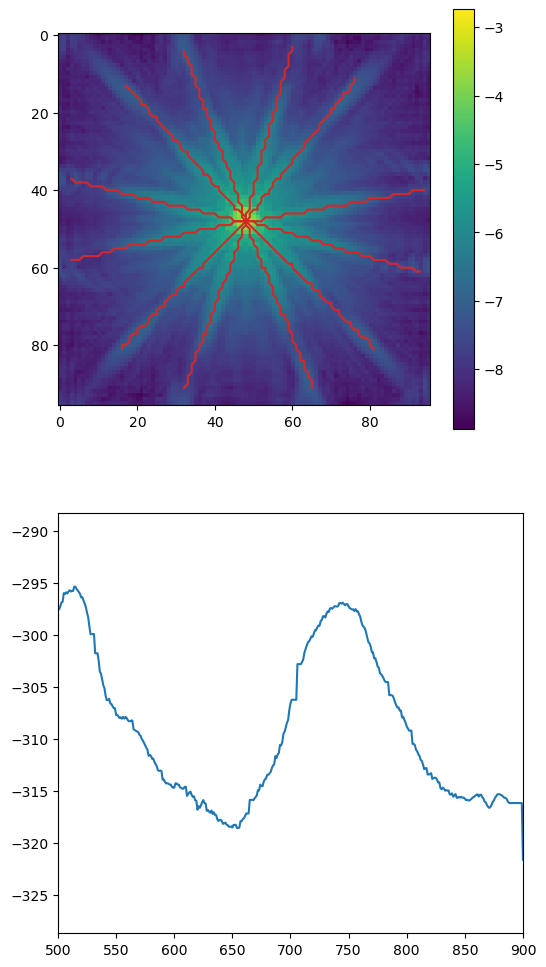

In [51]:
dsamp_poly_unfocused = downsample_2d_image( poly_unfocused, pixel_size=8 )
bound = dsamp_poly_unfocused.shape[0] // 2
center = np.array( ( bound, bound ) )

sums, _, _, spike_list_dunfocused = find_spikes( dsamp_poly_unfocused, 0.1, bound, center, verbose=True )

dsamp_poly_ideal = downsample_2d_image( poly_ideal, pixel_size=8 )
sums2, _, _, spike_list_dideal = find_spikes( dsamp_poly_ideal, 0.1, bound, center, verbose=True )

dsamp_poly_unfocused_n = downsample_2d_image( poly_unfocused_n, pixel_size=8 )
dsamp_poly_unfocused_small = downsample_2d_image( poly_unfocused_small, pixel_size=8 )

fig, ax = plt.subplots( figsize=( 6, 12 ), nrows=2 )
im = ax[0].imshow( dsamp_poly_unfocused )
fig.colorbar( im, ax=ax[0] )

ax[1].plot( sums )
ax[1].set_xlim( 500, 900 )

for spike, ispike in zip( spike_list_dunfocused, spike_list_dideal ):
    draw_ray( ax[0], spike, bound, center, color="C3" )

# draw_ray( ax[0], 22.2, bound, center, color="C3" )
# draw_ray( ax[0], 22.3, bound, center, color="C3" )


# ax[0].set_xlim( 72, 77 )
# ax[0].set_ylim( 40, 35 )

Comparing fits of the downsampled PSF to the oversampled ones

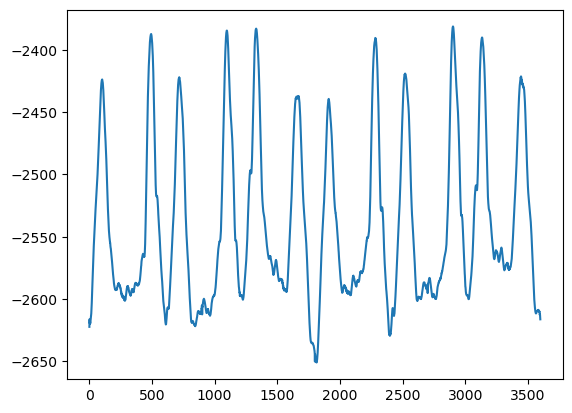

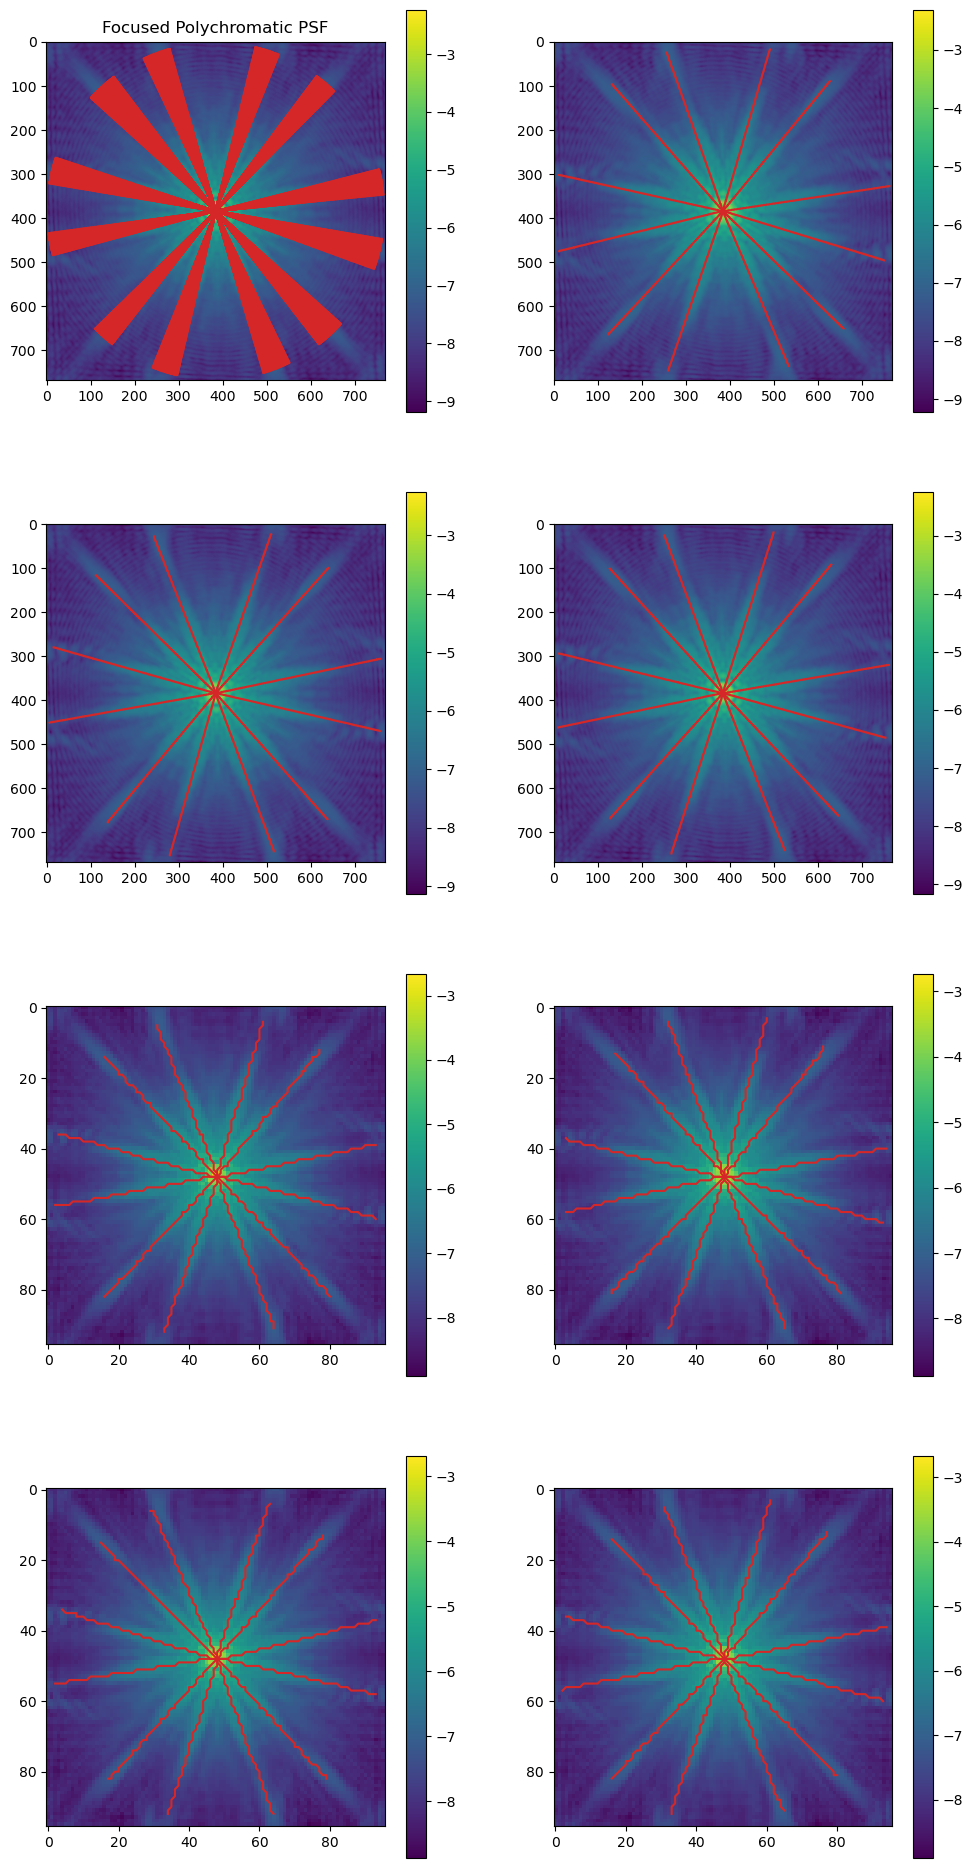

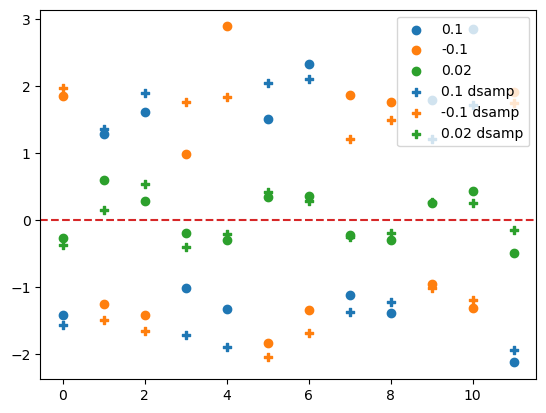

In [52]:
bound = poly_ideal.shape[0] // 2
center = np.array( ( poly_ideal.shape[0] // 2, poly_ideal.shape[0] // 2 ) )

dsamp_bound = dsamp_poly_ideal.shape[0] // 2
dsamp_center = np.array( ( dsamp_poly_ideal.shape[0] // 2, dsamp_poly_ideal.shape[0] // 2 ) )

# bound2 = img2.shape[0] // 2
# center2 = np.array( ( img2.shape[0] // 2, img2.shape[0] // 2 ) )


sums, spike_angles_ideal, cutoff, spike_list_ideal = find_spikes( poly_ideal, 0.1, bound, center, verbose=True )
plt.plot( sums )

sums, _, _, spike_list_unfocused = find_spikes( poly_unfocused, 0.1, bound, center, verbose=True )
# plt.plot( sums )

fig, ax = plt.subplots( figsize=( 12, 24 ), ncols=2, nrows=4 )
im = ax[0,0].imshow( poly_ideal )
fig.colorbar( im, ax=ax[0,0] )

im = ax[0,1].imshow( poly_unfocused )
fig.colorbar( im, ax=ax[0,1] )

im = ax[1,0].imshow( poly_unfocused_n )
fig.colorbar( im, ax=ax[1,0] )

im = ax[1,1].imshow( poly_unfocused_small )
fig.colorbar( im, ax=ax[1,1] )

im = ax[2,0].imshow( dsamp_poly_ideal )
fig.colorbar( im, ax=ax[2,0] )

im = ax[2,1].imshow( dsamp_poly_unfocused )
fig.colorbar( im, ax=ax[2,1] )

im = ax[3,0].imshow( dsamp_poly_unfocused_n )
fig.colorbar( im, ax=ax[3,0] )

im = ax[3,1].imshow( dsamp_poly_unfocused_small )
fig.colorbar( im, ax=ax[3,1] )

for spike in spike_angles_ideal:
    draw_ray( ax[0,0], spike, bound, center, color="C3" )

# spike_list_unfocused = find_spikes( poly_unfocused, 0.1, bound, center, exclude_center=True )
# spike_list_unfocused_n = find_spikes( poly_unfocused_n, 0.1, bound, center, exclude_center=True )
# spike_list_unfocused_small = find_spikes( poly_unfocused_small, 0.1, bound, center, exclude_center=True )

spike_list_unfocused = find_spikes( poly_unfocused, 0.1, bound, center )
spike_list_unfocused_n = find_spikes( poly_unfocused_n, 0.1, bound, center )
spike_list_unfocused_small = find_spikes( poly_unfocused_small, 0.1, bound, center )

spike_list_dunfocused_n = find_spikes( dsamp_poly_unfocused_n, 0.1, dsamp_bound, dsamp_center )
spike_list_dunfocused_small = find_spikes( dsamp_poly_unfocused_small, 0.1, dsamp_bound, dsamp_center )
                                       
for s, s2, s3, s4, s5, s6, s7 in zip(
    spike_list_unfocused, spike_list_unfocused_n, spike_list_unfocused_small,
    spike_list_dideal, spike_list_dunfocused, spike_list_dunfocused_n, spike_list_dunfocused_small
):
    draw_ray( ax[0,1], s, bound, center, color="C3" )
    draw_ray( ax[1,0], s2, bound, center, color="C3" )
    draw_ray( ax[1,1], s3, bound, center, color="C3" )
    draw_ray( ax[2,0], s4, dsamp_bound, dsamp_center, color="C3" )
    draw_ray( ax[2,1], s5, dsamp_bound, dsamp_center, color="C3" )
    draw_ray( ax[3,0], s6, dsamp_bound, dsamp_center, color="C3" )
    draw_ray( ax[3,1], s7, dsamp_bound, dsamp_center, color="C3" )

ax[0,0].set_title( 'Focused Polychromatic PSF' )

N = np.arange( spike_list_unfocused.size )
fig, ax = plt.subplots( )
ax.scatter( N, spike_list_unfocused - spike_list_ideal, label='0.1' )
ax.scatter( N, spike_list_unfocused_n - spike_list_ideal, label='-0.1' )
ax.scatter( N, spike_list_unfocused_small - spike_list_ideal, label='0.02' )
ax.scatter( N, spike_list_dunfocused - spike_list_dideal, label='0.1 dsamp', marker='P', color="C0" )
ax.scatter( N, spike_list_dunfocused_n - spike_list_dideal, label='-0.1 dsamp', marker='P', color="C1" )
ax.scatter( N, spike_list_dunfocused_small - spike_list_dideal, label='0.02 dsamp', marker='P', color="C2" )
ax.axhline( 0, color='C3', ls='--' )
ax.legend( );


The matrix equation we care about is $ \vec{\Delta \theta} = M \vec{\Delta Z} $. $\vec{\Delta \theta}$ is 12x1, $M$ is 12x5, $\vec{\Delta Z}$ is 5x1

Building a response matrix by generating a PSF from one aberration at a time, this strategy allows us to easily pick out columns of the response matrix.

In [53]:
def compute_response_matrix( aberrations, psf_object, **kwargs ): # will add more args to this later. for now it has np.linspace( 1.4, 1.8, 10 ) wavelengths, downsampled
    resp_matrix = np.zeros( ( 12, 5 ) )
    for i in np.arange( aberrations.size ):
        extra_aberrations = [ None, None, None, None, None ]
        extra_aberrations[i] = aberrations[i]
        
        psf_object.compute_poly_psf(
            postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96,
            ovsamp=8, extra_aberrations=extra_aberrations
        )
        
        psf_ovsamp = np.log10( np.abs( psf_object.chromatic_psf ) )
        psf = downsample_2d_image( psf_ovsamp, pixel_size=8 )
    
        spike_list = find_spikes( psf, 0.1, dsamp_bound, dsamp_center, **kwargs )
        resp_matrix[:, i] = ( spike_list - spike_list_dideal ) / aberrations[i]

    return resp_matrix

In [54]:
borders = ( 0.3, 1. )
spike_list_dideal = find_spikes( dsamp_poly_ideal, 0.1, dsamp_bound, dsamp_center, borders=borders )

aberrations = np.full( 5, 0.04 )
resp_matrix_04 = compute_response_matrix( aberrations, poly, borders=borders )

aberrations = np.full( 5, 0.07 )
resp_matrix_07 = compute_response_matrix( aberrations, poly, borders=borders )

aberrations = np.full( 5, 0.1 )
resp_matrix_10 = compute_response_matrix( aberrations, poly, borders=borders )

aberrations = np.full( 5, 0.13 )
resp_matrix_13 = compute_response_matrix( aberrations, poly, borders=borders )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


In [55]:
rng = np.random.default_rng( )

# test_aberrations = [ 0.085, 0, 0, 0, 0 ]
test_aberrations = rng.random( 5 ) * 0.2
# test_aberrations[ 1: ] = 0
print( f'Test Aberration Values: {test_aberrations}' )

poly.compute_poly_psf(
    postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96,
    ovsamp=8, extra_aberrations=test_aberrations
);
test_psf_ovsamp = np.log10( np.abs( poly.chromatic_psf ) )
test_psf = downsample_2d_image( test_psf_ovsamp, 8 )

Test Aberration Values: [0.00474286 0.01159397 0.07489564 0.03821924 0.0642074 ]


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


Take the random set of aberrations from above and try to predict the angle differences

(-248.0, -228.0)

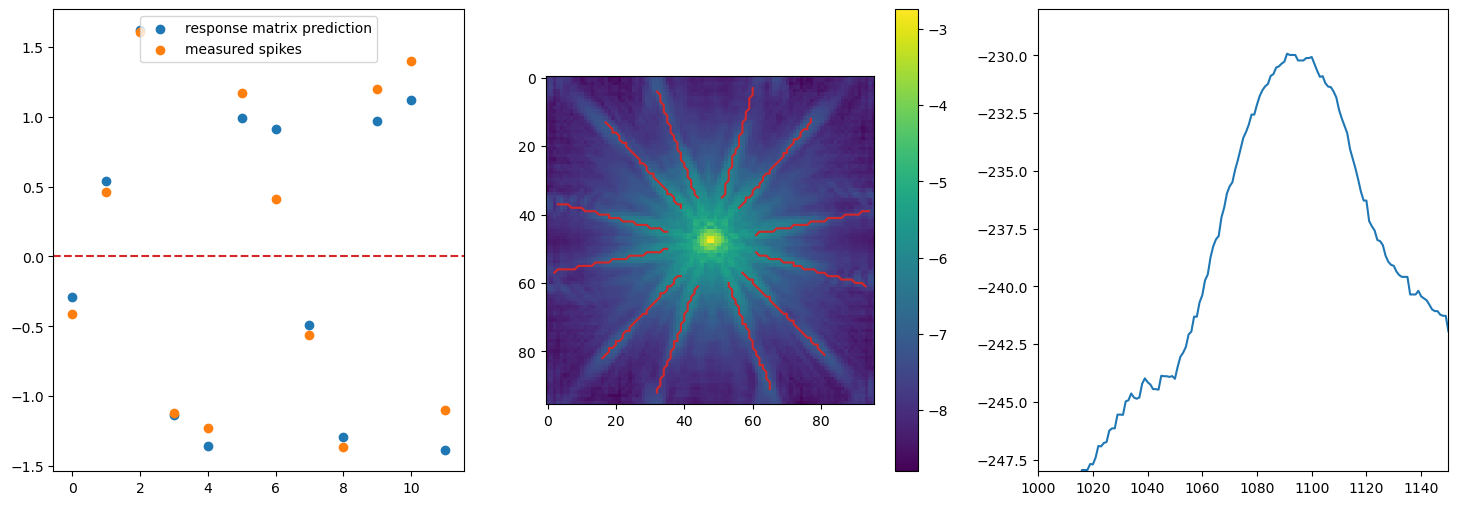

In [56]:
# print( resp_matrix_04 )
# print( resp_matrix_07 )
# print( resp_matrix_10 )
# print( resp_matrix_13 )

# print( rng.random( 5 ) )
# test_aberrations = [ 0.085, 0, 0, 0, 0 ]

big_resp_matrix = np.zeros( ( 12, 5, 4 ) )
big_resp_matrix[ :, :, 0 ] = resp_matrix_04
big_resp_matrix[ :, :, 1 ] = resp_matrix_07
big_resp_matrix[ :, :, 2 ] = resp_matrix_10
big_resp_matrix[ :, :, 3 ] = resp_matrix_13
resp_matrix = np.mean( big_resp_matrix, axis=-1 )


predict_angle_diffs = resp_matrix_07 @ np.array( test_aberrations )
sums, _, _, spike_list_test = find_spikes( test_psf, 0.1, dsamp_bound, dsamp_center, borders=borders, verbose=True )

dth_vec = spike_list_test - spike_list_dideal
# predict_aberrations = np.linalg.inv( resp_matrix.T @ resp_matrix ) @ resp_matrix.T @ dth_vec
N = np.arange( spike_list_test.size )


# print( predict_aberrations )

fig, ax = plt.subplots( figsize=( 18, 6 ), ncols=3 )

ax[0].scatter( N, predict_angle_diffs, label='response matrix prediction' )
ax[0].scatter( N, spike_list_test - spike_list_dideal, label='measured spikes' )
ax[0].axhline( 0, color='C3', ls='--' )
ax[0].legend( )

im = ax[1].imshow( test_psf )
fig.colorbar( im, ax=ax[1] )

# with np.printoptions( precision=4, floatmode='fixed' ):
#     ax[1].set_title( f'{test_aberrations}' )

for s in spike_list_test:
    draw_ray( ax[1], s, dsamp_bound, dsamp_center, borders=borders, color='C3' )

ax[2].plot( sums )
ax[2].set_xlim( 1000, 1150 )
ax[2].set_ylim( -248, -228 )

Text(0.5, 1.0, 'Differences between predicted and measured angle differences')

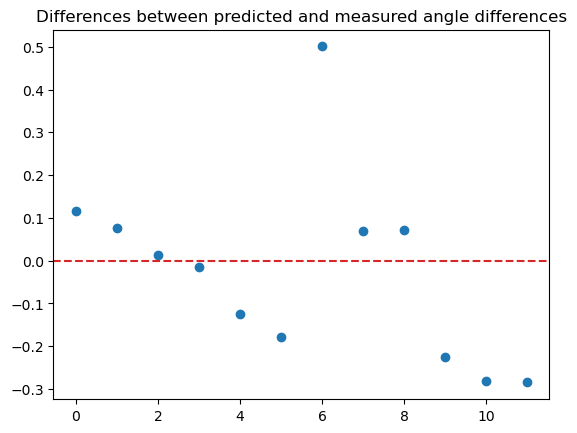

In [57]:
plt.scatter( N, predict_angle_diffs - ( spike_list_test - spike_list_dideal ) )
plt.axhline( 0, color='C3', ls='--' )
plt.title( 'Differences between predicted and measured angle differences' )

In [58]:
poly.compute_poly_psf(
            postage_stamp_size=32, optical_psf_only=True, use_postage_stamp_size = 96,
            ovsamp=8
)
poly_ideal_nolog = poly.chromatic_psf
dsamp_poly_ideal_nolog = downsample_2d_image( poly_ideal_nolog, 8 )
dsamp_poly_ideal = np.log10( np.abs( dsamp_poly_ideal_nolog ) )

/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


...

Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


/apps/python/3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/apps/python/3.12/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Bounding pupil width determined from initial ray trace: 2859.38 mm


Poisson resampling a PSF given some magnitude (\# of electrons). This version breaks if any pixels are zero due to the use of `np.log10`. 

0.9999999999999998
0.015624999999999997


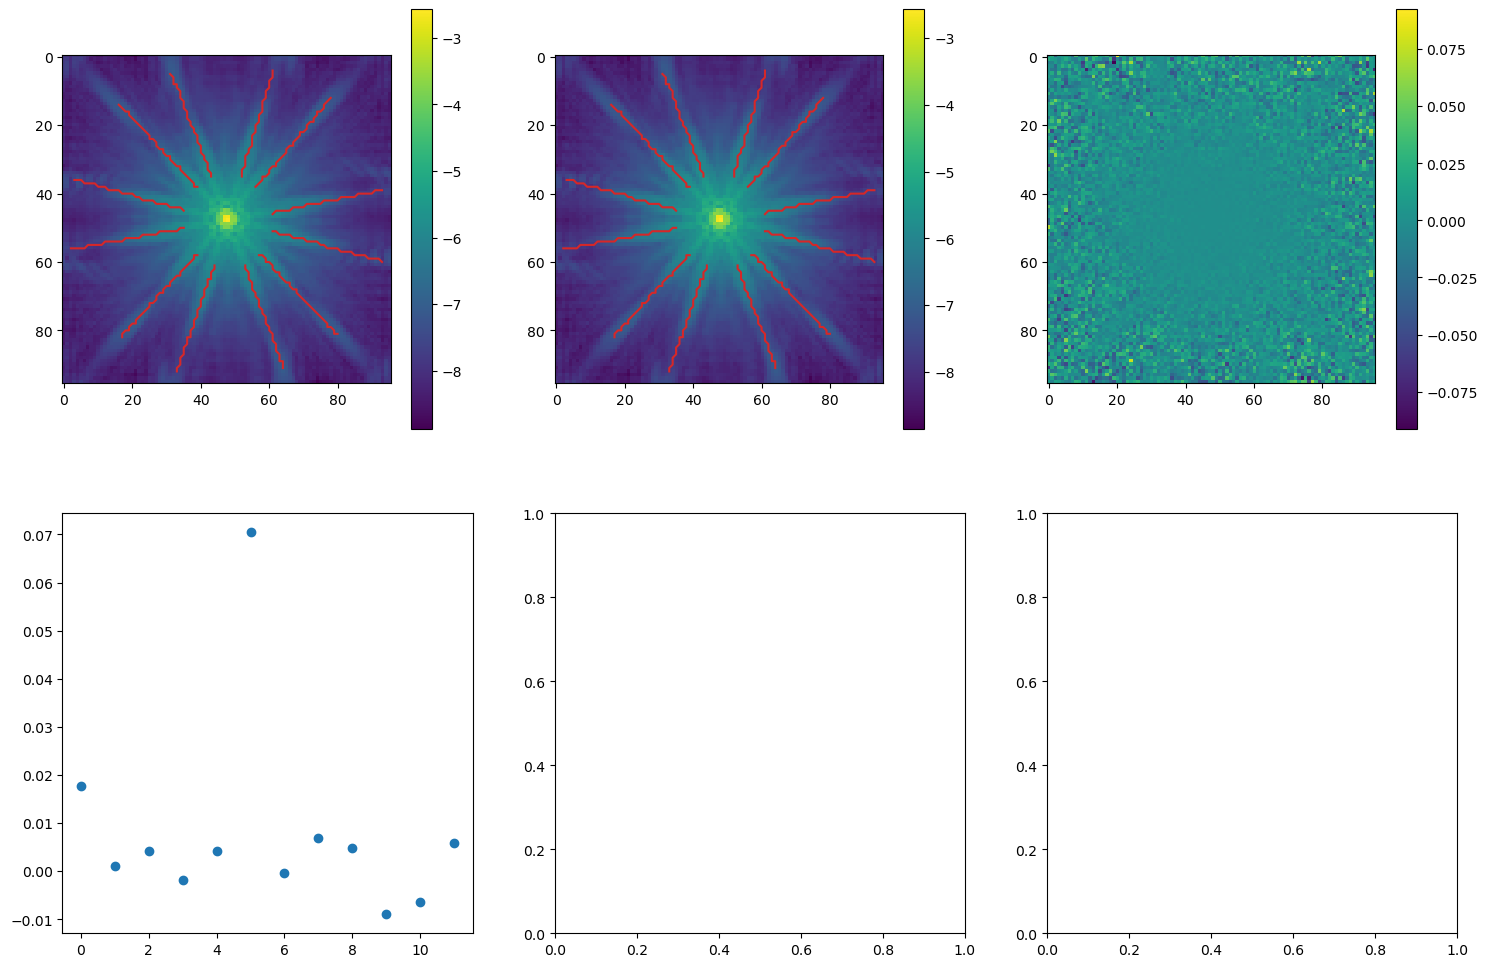

In [59]:
print( np.sum( poly_ideal_nolog ) )
print( np.sum( dsamp_poly_ideal_nolog ) )


def poisson_resample_image( img, flux_factor ):
    # resamples an image where each pixel gets its own poisson distribution
    rng = np.random.default_rng( )
    poisson_means = img * flux_factor

    # this version tries to renormalize the image to the given image's sum which is an alright approach when using log10 to get logspace.
    resampled_img = rng.poisson( poisson_means, size=poisson_means.shape ) / flux_factor
    return resampled_img



fig, ax = plt.subplots( figsize=( 18, 12 ), nrows=2, ncols=3 )


im = ax[0,0].imshow( dsamp_poly_ideal )
fig.colorbar( im, ax=ax[0,0] )

# Due to the use of log10 the magnitude for these needs to be quite large to make sure no pixel gets 0 electrons.
flux_factor = 64 * 1e9

dsamp_poly_ideal_noise_nolog = poisson_resample_image( dsamp_poly_ideal_nolog, flux_factor )
dsamp_poly_ideal_noise = np.log10( np.abs( dsamp_poly_ideal_noise_nolog ) )


im = ax[0,1].imshow( dsamp_poly_ideal_noise )
fig.colorbar( im, ax=ax[0,1] )

im = ax[0,2].imshow( dsamp_poly_ideal_noise - dsamp_poly_ideal )
fig.colorbar( im, ax=ax[0,2] )

spike_list_dideal = find_spikes( dsamp_poly_ideal, 0.1, dsamp_bound, dsamp_center, borders=borders )
spike_list_dideal_noise = find_spikes( dsamp_poly_ideal_noise, 0.1, dsamp_bound, dsamp_center, borders=borders )

for s1, s2 in zip( spike_list_dideal, spike_list_dideal_noise ):
    draw_ray( ax[0,0], s1, dsamp_bound, dsamp_center, borders=borders, color='C3' )
    draw_ray( ax[0,1], s2, dsamp_bound, dsamp_center, borders=borders, color='C3' )

ax[1,0].scatter( N, spike_list_dideal_noise - spike_list_dideal )



This version of Poisson resampling changes the normalization of the image but works far better in the case where some pixels have no signal due to the use of `arcsinh`.

[ 12.03808511  50.01660775  72.79958009 111.42870841 132.98148715
 164.41271037 190.86611243 227.09392606 250.85518061 291.18953153
 313.84890316 345.02048922]
100000283401


Text(0.5, 1.0, 'Spike Angle Residuals vs. Ideal PSF')

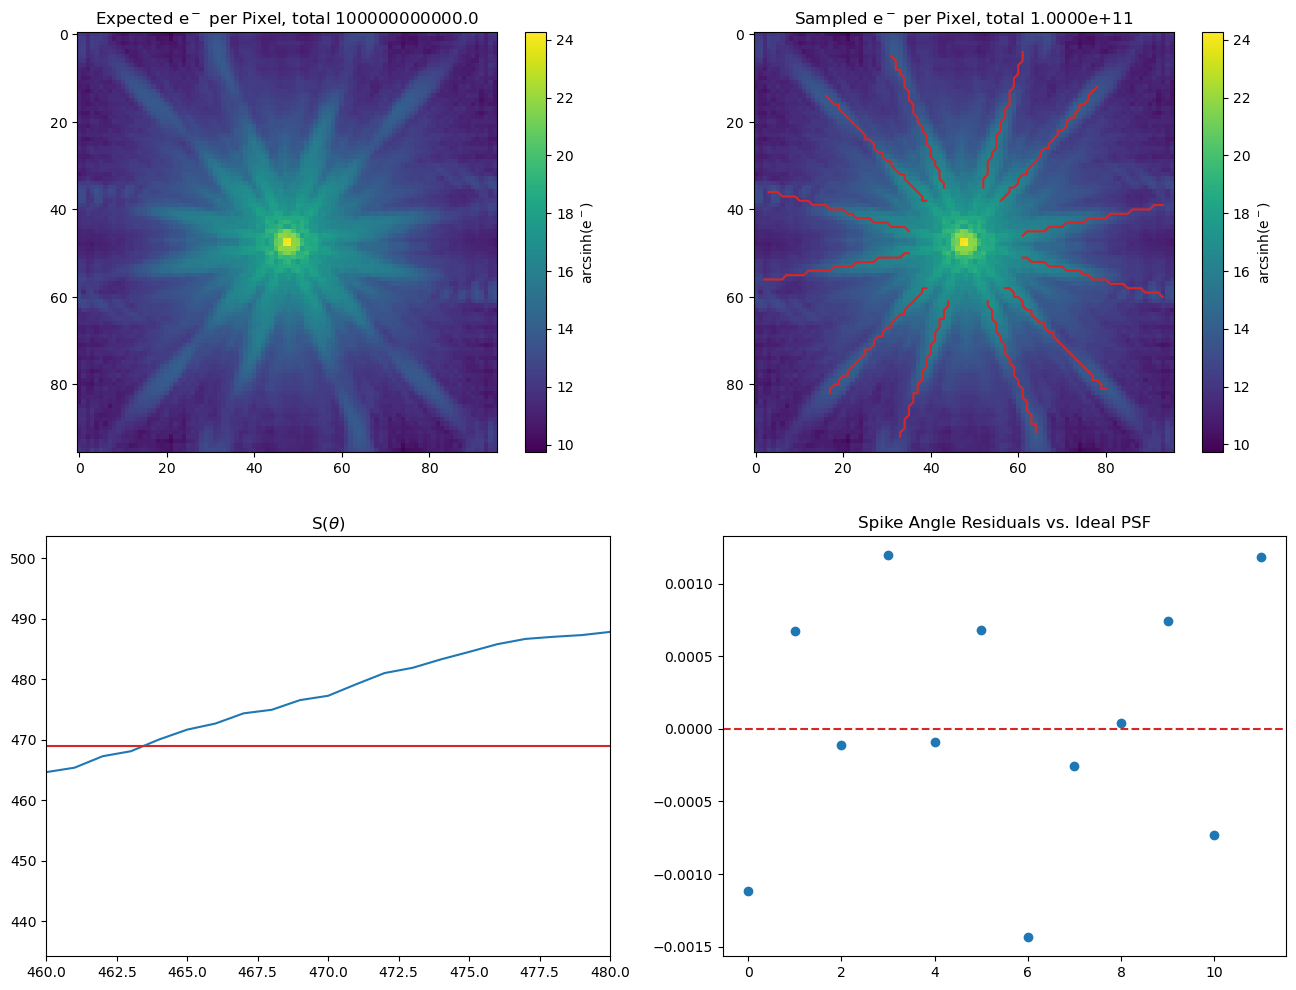

In [80]:
# plt.imshow( dsamp_poly_ideal_nolog * 64e8 )
flux_factor = 64 * 1e11
poisson_means = np.abs( dsamp_poly_ideal_nolog * flux_factor )

rng = np.random.default_rng( )
dsamp_poly_ideal_noise_nolog = rng.poisson( lam=poisson_means, size=poisson_means.shape )

sums, _, cutoff, spikes_noisy = find_spikes( np.arcsinh( dsamp_poly_ideal_noise_nolog ), 0.1, dsamp_bound, dsamp_center, borders=borders, verbose=True )
spikes_ideal = find_spikes( dsamp_poly_ideal, 0.1, dsamp_bound, dsamp_center, borders=borders )

# plt.plot( sums )
print( spikes_noisy )
# plt.xlim( 300, 600 )
# plt.ylim( 0.00578, 0.00580 )

fig, ax = plt.subplots( figsize=( 16, 12 ), ncols=2, nrows=2 )
im = ax[0,0].imshow( np.arcsinh( poisson_means ) )
ax[0,0].set_title( r'Expected $\text{e}^-$ per Pixel, ' + f'total {(flux_factor/64)}' )
# im = ax[0,0].imshow( ( poisson_means ) )
fig.colorbar( im, ax=ax[0,0], label=r'arcsinh($\text{e}^-$)' )
# ax[0,0].legend( )
print( np.sum( dsamp_poly_ideal_noise_nolog ) )
im = ax[0,1].imshow( np.arcsinh( dsamp_poly_ideal_noise_nolog ) )
ax[0,1].set_title( r'Sampled $\text{e}^-$ per Pixel, total ' + f'{np.sum( dsamp_poly_ideal_noise_nolog ):.4e}' )
# im = ax[0,1].imshow( ( dsamp_poly_ideal_noise_nolog ) )
for s in spikes_noisy:
    draw_ray( ax[0,1], s, dsamp_bound, dsamp_center, borders=borders, color='C3' )

fig.colorbar( im, ax=ax[0,1], label=r'arcsinh($\text{e}^-$)' )

# angles = np.linspace( 0, 359.9, np.int_( 360/0.1 ) )
# ax[1,0].plot( angles, sums )
ax[1,0].plot( sums )
ax[1,0].set_title( r'S($\theta$)' )
ax[1,0].axhline( cutoff, color='C3' )
ax[1,0].set_xlim( 460, 480 )

N = np.arange( spikes_ideal.size )
ax[1,1].scatter( N, spikes_noisy - spikes_ideal )
ax[1,1].axhline( 0, ls='--', color='C3' )
ax[1,1].set_title( 'Spike Angle Residuals vs. Ideal PSF' )
# plt.show( )
